In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.io import wavfile

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = None
for candidate in candidate_roots:
    if (candidate / "src").exists() and (candidate / "data").exists():
        project_root = candidate.resolve()
        break

if project_root is None:
    raise RuntimeError("Could not locate the project root containing 'src' and 'data'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.data.dataset as dataset_module
from src.data.dataset import MIMIIDataset
from src.data.transforms import BaselineLogMelTransform
from src.features.spectrogram import LogMelSpectrogramExtractor
from src.features.waveform import average_channels_to_mono

MANIFEST_PATH = "../data/splits/fan_split_seed42.csv"
SPLIT_NAME = "test"
EXPECTED_RAW_SHAPE = (8, 160000)
EXPECTED_SAMPLE_RATE = 16000
PREPROCESSING_PARAMS = {
    "sample_rate": 16000,
    "n_fft": 1024,
    "win_length": 1024,
    "hop_length": 512,
    "n_mels": 64,
    "f_min": 0.0,
    "f_max": 8000.0,
}
LABEL_INDEX_TO_NAME = {
    0: "normal",
    1: "abnormal",
}


def scipy_torchaudio_load(
    uri,
    frame_offset=0,
    num_frames=-1,
    normalize=True,
    channels_first=True,
    format=None,
    buffer_size=4096,
    backend=None,
):
    """Notebook-local WAV loader used so MIMIIDataset works without torchcodec."""
    del format, buffer_size, backend

    sample_rate, data = wavfile.read(Path(uri))
    if data.ndim == 1:
        data = data[:, None]

    if frame_offset:
        data = data[frame_offset:]
    if num_frames != -1:
        data = data[:num_frames]

    waveform = torch.from_numpy(data)
    if normalize:
        if waveform.dtype == torch.int16:
            waveform = waveform.to(torch.float32) / 32768.0
        elif waveform.dtype == torch.int32:
            waveform = waveform.to(torch.float32) / 2147483648.0
        elif waveform.dtype == torch.uint8:
            waveform = (waveform.to(torch.float32) - 128.0) / 128.0
        else:
            waveform = waveform.to(torch.float32)

    if channels_first:
        waveform = waveform.transpose(0, 1)

    return waveform.contiguous(), int(sample_rate)


# Patch only inside this notebook so the requested dataset entry point remains unchanged.
dataset_module.torchaudio.load = scipy_torchaudio_load

print(f"Project root: {project_root}")
print(f"Manifest: {MANIFEST_PATH}")
print(f"Split: {SPLIT_NAME}")
print(f"Baseline parameters: {PREPROCESSING_PARAMS}")

Project root: /Users/gynnyeo/Documents/GitHub/Anomalous-Machine-Sound-Detection
Manifest: ../data/splits/fan_split_seed42.csv
Split: test
Baseline parameters: {'sample_rate': 16000, 'n_fft': 1024, 'win_length': 1024, 'hop_length': 512, 'n_mels': 64, 'f_min': 0.0, 'f_max': 8000.0}


Visualize each preprocessing stage for one normal and one abnormal MIMII fan sample.

In [14]:
dataset = MIMIIDataset(
    manifest_path=MANIFEST_PATH,
    split=SPLIT_NAME,
    transform=None,
    return_metadata=True,
)

records = dataset._records
first_normal_index = None
first_abnormal_index = None
first_normal_by_group = {}
first_abnormal_by_group = {}
first_normal_by_machine_snr = {}
first_abnormal_by_machine_snr = {}

for index, record in enumerate(records):
    label_name = record["label"]
    group_id = record["group_id"]
    machine_snr_key = (record["machine_id"], record["snr_db"])

    if label_name == "normal":
        if first_normal_index is None:
            first_normal_index = index
        if group_id not in first_normal_by_group:
            first_normal_by_group[group_id] = index
        if machine_snr_key not in first_normal_by_machine_snr:
            first_normal_by_machine_snr[machine_snr_key] = index
    elif label_name == "abnormal":
        if first_abnormal_index is None:
            first_abnormal_index = index
        if group_id not in first_abnormal_by_group:
            first_abnormal_by_group[group_id] = index
        if machine_snr_key not in first_abnormal_by_machine_snr:
            first_abnormal_by_machine_snr[machine_snr_key] = index
    else:
        raise ValueError(f"Unexpected label found in manifest record: {label_name}")

selected_reason = None
normal_index = None
abnormal_index = None
seen_group_ids = set()
for record in records:
    group_id = record["group_id"]
    if group_id in seen_group_ids:
        continue
    seen_group_ids.add(group_id)
    if group_id in first_normal_by_group and group_id in first_abnormal_by_group:
        normal_index = first_normal_by_group[group_id]
        abnormal_index = first_abnormal_by_group[group_id]
        selected_reason = f"Matched by shared group_id: {group_id}"
        break

if normal_index is None or abnormal_index is None:
    seen_machine_snr_keys = set()
    for record in records:
        machine_snr_key = (record["machine_id"], record["snr_db"])
        if machine_snr_key in seen_machine_snr_keys:
            continue
        seen_machine_snr_keys.add(machine_snr_key)
        if (
            machine_snr_key in first_normal_by_machine_snr
            and machine_snr_key in first_abnormal_by_machine_snr
        ):
            normal_index = first_normal_by_machine_snr[machine_snr_key]
            abnormal_index = first_abnormal_by_machine_snr[machine_snr_key]
            selected_reason = (
                "Matched by shared machine_id and snr_db: "
                f"machine_id={machine_snr_key[0]}, snr_db={machine_snr_key[1]}"
            )
            break

if normal_index is None or abnormal_index is None:
    if first_normal_index is None or first_abnormal_index is None:
        raise RuntimeError("Could not find both a normal sample and an abnormal sample.")
    normal_index = first_normal_index
    abnormal_index = first_abnormal_index
    selected_reason = "Fallback to the first normal sample and the first abnormal sample in dataset order"

normal_sample = dataset[normal_index]
abnormal_sample = dataset[abnormal_index]
selected_samples = {
    "Normal": normal_sample,
    "Abnormal": abnormal_sample,
}

print(f"Dataset size for split '{SPLIT_NAME}': {len(dataset)}")
print(f"Selection rule used: {selected_reason}")

required_sample_keys = {"waveform", "sample_rate", "label", "metadata"}
for sample_type, sample in selected_samples.items():
    missing_keys = required_sample_keys.difference(sample.keys())
    if missing_keys:
        raise KeyError(f"{sample_type} sample is missing keys: {sorted(missing_keys)}")

    metadata = sample["metadata"]
    label_name = LABEL_INDEX_TO_NAME[sample["label"]]
    print(f"\n{sample_type} sample")
    print(f"  dataset index: {normal_index if sample_type == 'Normal' else abnormal_index}")
    print(f"  label: {label_name}")
    print(f"  waveform shape: {tuple(sample['waveform'].shape)}")
    print(f"  sample rate: {sample['sample_rate']}")
    print(f"  filepath: {metadata['filepath']}")
    print(f"  machine_type: {metadata['machine_type']}")
    print(f"  machine_id: {metadata['machine_id']}")
    print(f"  snr_db: {metadata['snr_db']}")
    print(f"  group_id: {metadata['group_id']}")
    print(f"  split: {metadata['split']}")

Dataset size for split 'test': 2799
Selection rule used: Matched by shared group_id: id_00__0_dB

Normal sample
  dataset index: 407
  label: normal
  waveform shape: (8, 160000)
  sample rate: 16000
  filepath: data/raw/0_dB_fan/id_00/normal/00000000.wav
  machine_type: fan
  machine_id: id_00
  snr_db: 0_dB
  group_id: id_00__0_dB
  split: test

Abnormal sample
  dataset index: 0
  label: abnormal
  waveform shape: (8, 160000)
  sample rate: 16000
  filepath: data/raw/0_dB_fan/id_00/abnormal/00000000.wav
  machine_type: fan
  machine_id: id_00
  snr_db: 0_dB
  group_id: id_00__0_dB
  split: test


In [15]:
log_mel_extractor = LogMelSpectrogramExtractor(**PREPROCESSING_PARAMS)
baseline_transform = BaselineLogMelTransform(**PREPROCESSING_PARAMS)

normal_raw_waveform = normal_sample["waveform"]
normal_sample_rate = normal_sample["sample_rate"]
normal_mono_waveform = average_channels_to_mono(normal_raw_waveform)
normal_stft = torch.stft(
    normal_mono_waveform,
    n_fft=PREPROCESSING_PARAMS["n_fft"],
    hop_length=PREPROCESSING_PARAMS["hop_length"],
    win_length=PREPROCESSING_PARAMS["win_length"],
    window=torch.hann_window(
        PREPROCESSING_PARAMS["win_length"],
        dtype=normal_mono_waveform.dtype,
        device=normal_mono_waveform.device,
    ),
    center=True,
    pad_mode="reflect",
    normalized=False,
    onesided=True,
    return_complex=True,
)
normal_stft_magnitude = normal_stft.abs()
normal_power_spectrogram = normal_stft_magnitude.pow(2.0)
normal_mel_spectrogram = log_mel_extractor.mel_transform.mel_scale(normal_power_spectrogram)
normal_log_mel_spectrogram = log_mel_extractor.db_transform(normal_mel_spectrogram).to(dtype=torch.float32)
normal_log_mel_from_extractor = log_mel_extractor(normal_mono_waveform, sample_rate=normal_sample_rate)
normal_model_input = baseline_transform(normal_sample)["input"]

abnormal_raw_waveform = abnormal_sample["waveform"]
abnormal_sample_rate = abnormal_sample["sample_rate"]
abnormal_mono_waveform = average_channels_to_mono(abnormal_raw_waveform)
abnormal_stft = torch.stft(
    abnormal_mono_waveform,
    n_fft=PREPROCESSING_PARAMS["n_fft"],
    hop_length=PREPROCESSING_PARAMS["hop_length"],
    win_length=PREPROCESSING_PARAMS["win_length"],
    window=torch.hann_window(
        PREPROCESSING_PARAMS["win_length"],
        dtype=abnormal_mono_waveform.dtype,
        device=abnormal_mono_waveform.device,
    ),
    center=True,
    pad_mode="reflect",
    normalized=False,
    onesided=True,
    return_complex=True,
)
abnormal_stft_magnitude = abnormal_stft.abs()
abnormal_power_spectrogram = abnormal_stft_magnitude.pow(2.0)
abnormal_mel_spectrogram = log_mel_extractor.mel_transform.mel_scale(abnormal_power_spectrogram)
abnormal_log_mel_spectrogram = log_mel_extractor.db_transform(abnormal_mel_spectrogram).to(dtype=torch.float32)
abnormal_log_mel_from_extractor = log_mel_extractor(abnormal_mono_waveform, sample_rate=abnormal_sample_rate)
abnormal_model_input = baseline_transform(abnormal_sample)["input"]

if not torch.allclose(normal_log_mel_spectrogram, normal_log_mel_from_extractor):
    raise AssertionError("Normal log-mel spectrogram does not match LogMelSpectrogramExtractor output.")
if not torch.allclose(abnormal_log_mel_spectrogram, abnormal_log_mel_from_extractor):
    raise AssertionError("Abnormal log-mel spectrogram does not match LogMelSpectrogramExtractor output.")
if not torch.allclose(normal_model_input.squeeze(0), normal_log_mel_spectrogram):
    raise AssertionError("Normal model input does not match the explicitly computed log-mel spectrogram.")
if not torch.allclose(abnormal_model_input.squeeze(0), abnormal_log_mel_spectrogram):
    raise AssertionError("Abnormal model input does not match the explicitly computed log-mel spectrogram.")

normal_stages = {
    "raw_waveform": normal_raw_waveform,
    "mono_waveform": normal_mono_waveform,
    "stft": normal_stft,
    "stft_magnitude": normal_stft_magnitude,
    "power_spectrogram": normal_power_spectrogram,
    "mel_spectrogram": normal_mel_spectrogram,
    "log_mel_spectrogram": normal_log_mel_spectrogram,
    "model_input": normal_model_input,
}

abnormal_stages = {
    "raw_waveform": abnormal_raw_waveform,
    "mono_waveform": abnormal_mono_waveform,
    "stft": abnormal_stft,
    "stft_magnitude": abnormal_stft_magnitude,
    "power_spectrogram": abnormal_power_spectrogram,
    "mel_spectrogram": abnormal_mel_spectrogram,
    "log_mel_spectrogram": abnormal_log_mel_spectrogram,
    "model_input": abnormal_model_input,
}

In [16]:
def print_stage_shapes(sample_type, sample_rate, stages):
    print(f"\n{sample_type} sample stage shapes")
    for stage_name in [
        "raw_waveform",
        "mono_waveform",
        "stft",
        "stft_magnitude",
        "power_spectrogram",
        "mel_spectrogram",
        "log_mel_spectrogram",
        "model_input",
    ]:
        print(f"  {stage_name}: {tuple(stages[stage_name].shape)}")

    assert sample_rate == EXPECTED_SAMPLE_RATE, f"Expected sample rate {EXPECTED_SAMPLE_RATE}, got {sample_rate}."
    assert stages["raw_waveform"].ndim == 2, "Raw waveform must be 2D."
    assert stages["mono_waveform"].ndim == 1, "Mono waveform must be 1D."
    assert stages["stft_magnitude"].ndim == 2, "STFT magnitude must be 2D."
    assert stages["power_spectrogram"].ndim == 2, "Power spectrogram must be 2D."
    assert stages["mel_spectrogram"].ndim == 2, "Mel spectrogram must be 2D."
    assert stages["log_mel_spectrogram"].ndim == 2, "Log-mel spectrogram must be 2D."
    assert stages["model_input"].ndim == 3, "Final model input must be 3D."
    assert stages["model_input"].shape[0] == 1, "Final model input first dimension must be 1."
    assert tuple(stages["raw_waveform"].shape) == EXPECTED_RAW_SHAPE, (
        f"Expected raw waveform shape {EXPECTED_RAW_SHAPE}, got {tuple(stages['raw_waveform'].shape)}."
    )
    assert tuple(stages["model_input"].shape) == (1, PREPROCESSING_PARAMS["n_mels"], 313), (
        "Expected final model input shape [1, 64, 313], "
        f"got {tuple(stages['model_input'].shape)}."
    )


print_stage_shapes("Normal", normal_sample_rate, normal_stages)
print_stage_shapes("Abnormal", abnormal_sample_rate, abnormal_stages)


Normal sample stage shapes
  raw_waveform: (8, 160000)
  mono_waveform: (160000,)
  stft: (513, 313)
  stft_magnitude: (513, 313)
  power_spectrogram: (513, 313)
  mel_spectrogram: (64, 313)
  log_mel_spectrogram: (64, 313)
  model_input: (1, 64, 313)

Abnormal sample stage shapes
  raw_waveform: (8, 160000)
  mono_waveform: (160000,)
  stft: (513, 313)
  stft_magnitude: (513, 313)
  power_spectrogram: (513, 313)
  mel_spectrogram: (64, 313)
  log_mel_spectrogram: (64, 313)
  model_input: (1, 64, 313)


In [17]:
def plot_multichannel_waveform(waveform, sample_rate, sample_type, save_path):
    num_channels, num_samples = waveform.shape
    time_axis = np.arange(num_samples) / sample_rate
    fig, axes = plt.subplots(num_channels, 1, figsize=(14, 14), sharex=True)
    for channel_index, axis in enumerate(axes):
        axis.plot(time_axis, waveform[channel_index].cpu().numpy(), linewidth=0.8)
        axis.set_ylabel(f"Ch {channel_index + 1}")
        axis.grid(alpha=0.2)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"{sample_type} | Raw Multichannel Waveform")
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_mono_waveform(waveform, sample_rate, sample_type, save_path):
    time_axis = np.arange(waveform.shape[0]) / sample_rate
    fig, axis = plt.subplots(figsize=(14, 4))
    axis.plot(time_axis, waveform.cpu().numpy(), linewidth=0.8)
    axis.set_title(f"{sample_type} | Mono Waveform")
    axis.set_xlabel("Time (s)")
    axis.set_ylabel("Amplitude")
    axis.grid(alpha=0.2)
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_matrix(matrix, sample_type, stage_name, save_path, x_label, y_label, colorbar_label):
    fig, axis = plt.subplots(figsize=(12, 5))
    image = axis.imshow(matrix.cpu().numpy(), aspect="auto", origin="lower", cmap="magma")
    axis.set_title(f"{sample_type} | {stage_name}")
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    colorbar = fig.colorbar(image, ax=axis)
    colorbar.set_label(colorbar_label)
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def plot_stft_magnitude_spectrogram(matrix, sample_type, save_path):
    plot_matrix(
        matrix=matrix,
        sample_type=sample_type,
        stage_name="STFT Magnitude Spectrogram",
        save_path=save_path,
        x_label="Frame",
        y_label="Frequency Bin",
        colorbar_label="Magnitude",
    )


def plot_power_spectrogram(matrix, sample_type, save_path):
    plot_matrix(
        matrix=matrix,
        sample_type=sample_type,
        stage_name="Power Spectrogram",
        save_path=save_path,
        x_label="Frame",
        y_label="Frequency Bin",
        colorbar_label="Power",
    )


def plot_mel_spectrogram(matrix, sample_type, save_path):
    plot_matrix(
        matrix=matrix,
        sample_type=sample_type,
        stage_name="Mel Spectrogram",
        save_path=save_path,
        x_label="Frame",
        y_label="Mel Bin",
        colorbar_label="Mel Power",
    )


def plot_log_mel_spectrogram(matrix, sample_type, save_path):
    plot_matrix(
        matrix=matrix,
        sample_type=sample_type,
        stage_name="Log-Mel Spectrogram",
        save_path=save_path,
        x_label="Frame",
        y_label="Mel Bin",
        colorbar_label="dB",
    )

In [18]:
artifact_root = project_root / "notebook" / "artifacts" / "preprocessing_visualizations"
normal_output_dir = artifact_root / "normal"
abnormal_output_dir = artifact_root / "abnormal"

normal_output_dir.mkdir(parents=True, exist_ok=True)
abnormal_output_dir.mkdir(parents=True, exist_ok=True)

print(f"Artifact root: {artifact_root}")
print(f"Normal output directory: {normal_output_dir}")
print(f"Abnormal output directory: {abnormal_output_dir}")

Artifact root: /Users/gynnyeo/Documents/GitHub/Anomalous-Machine-Sound-Detection/notebook/artifacts/preprocessing_visualizations
Normal output directory: /Users/gynnyeo/Documents/GitHub/Anomalous-Machine-Sound-Detection/notebook/artifacts/preprocessing_visualizations/normal
Abnormal output directory: /Users/gynnyeo/Documents/GitHub/Anomalous-Machine-Sound-Detection/notebook/artifacts/preprocessing_visualizations/abnormal


In [19]:
normal_saved_files = [
    normal_output_dir / "01_raw_waveform_multichannel.png",
    normal_output_dir / "02_mono_waveform.png",
    normal_output_dir / "03_stft_magnitude.png",
    normal_output_dir / "04_power_spectrogram.png",
    normal_output_dir / "05_mel_spectrogram.png",
    normal_output_dir / "06_log_mel_spectrogram.png",
]

abnormal_saved_files = [
    abnormal_output_dir / "01_raw_waveform_multichannel.png",
    abnormal_output_dir / "02_mono_waveform.png",
    abnormal_output_dir / "03_stft_magnitude.png",
    abnormal_output_dir / "04_power_spectrogram.png",
    abnormal_output_dir / "05_mel_spectrogram.png",
    abnormal_output_dir / "06_log_mel_spectrogram.png",
]

plot_multichannel_waveform(normal_raw_waveform, normal_sample_rate, "Normal", normal_saved_files[0])
plot_mono_waveform(normal_mono_waveform, normal_sample_rate, "Normal", normal_saved_files[1])
plot_stft_magnitude_spectrogram(normal_stft_magnitude, "Normal", normal_saved_files[2])
plot_power_spectrogram(normal_power_spectrogram, "Normal", normal_saved_files[3])
plot_mel_spectrogram(normal_mel_spectrogram, "Normal", normal_saved_files[4])
plot_log_mel_spectrogram(normal_log_mel_spectrogram, "Normal", normal_saved_files[5])

plot_multichannel_waveform(abnormal_raw_waveform, abnormal_sample_rate, "Abnormal", abnormal_saved_files[0])
plot_mono_waveform(abnormal_mono_waveform, abnormal_sample_rate, "Abnormal", abnormal_saved_files[1])
plot_stft_magnitude_spectrogram(abnormal_stft_magnitude, "Abnormal", abnormal_saved_files[2])
plot_power_spectrogram(abnormal_power_spectrogram, "Abnormal", abnormal_saved_files[3])
plot_mel_spectrogram(abnormal_mel_spectrogram, "Abnormal", abnormal_saved_files[4])
plot_log_mel_spectrogram(abnormal_log_mel_spectrogram, "Abnormal", abnormal_saved_files[5])

print("Saved figures:")
for saved_file in normal_saved_files + abnormal_saved_files:
    print(f"  {saved_file.relative_to(project_root)}")

Saved figures:
  notebook/artifacts/preprocessing_visualizations/normal/01_raw_waveform_multichannel.png
  notebook/artifacts/preprocessing_visualizations/normal/02_mono_waveform.png
  notebook/artifacts/preprocessing_visualizations/normal/03_stft_magnitude.png
  notebook/artifacts/preprocessing_visualizations/normal/04_power_spectrogram.png
  notebook/artifacts/preprocessing_visualizations/normal/05_mel_spectrogram.png
  notebook/artifacts/preprocessing_visualizations/normal/06_log_mel_spectrogram.png
  notebook/artifacts/preprocessing_visualizations/abnormal/01_raw_waveform_multichannel.png
  notebook/artifacts/preprocessing_visualizations/abnormal/02_mono_waveform.png
  notebook/artifacts/preprocessing_visualizations/abnormal/03_stft_magnitude.png
  notebook/artifacts/preprocessing_visualizations/abnormal/04_power_spectrogram.png
  notebook/artifacts/preprocessing_visualizations/abnormal/05_mel_spectrogram.png
  notebook/artifacts/preprocessing_visualizations/abnormal/06_log_mel_spe

In [20]:
normal_mono_rms = torch.sqrt(torch.mean(normal_mono_waveform.pow(2))).item()
abnormal_mono_rms = torch.sqrt(torch.mean(abnormal_mono_waveform.pow(2))).item()
normal_log_mel_mean = normal_log_mel_spectrogram.mean().item()
abnormal_log_mel_mean = abnormal_log_mel_spectrogram.mean().item()
normal_log_mel_std = normal_log_mel_spectrogram.std().item()
abnormal_log_mel_std = abnormal_log_mel_spectrogram.std().item()

print("Concise comparison across preprocessing stages")
print(
    f"- Both samples keep the same raw duration and move through the same deterministic pipeline to a final shape of {tuple(normal_model_input.shape)}."
)
print(
    f"- The mono waveforms have comparable scale, with RMS values of {normal_mono_rms:.4f} for the normal sample and {abnormal_mono_rms:.4f} for the abnormal sample."
)
mean_direction = "higher" if abnormal_log_mel_mean > normal_log_mel_mean else "lower"
print(
    f"- In this selected pair, the abnormal sample shows a {mean_direction} average log-mel intensity than the normal sample ({abnormal_log_mel_mean:.2f} dB vs {normal_log_mel_mean:.2f} dB)."
)
print(
    f"- The log-mel spread is similar but not identical, with standard deviations of {normal_log_mel_std:.2f} dB for normal and {abnormal_log_mel_std:.2f} dB for abnormal."
)
print(
    "- These are conservative visual and summary-statistic differences for this pair only, not a diagnostic claim about class separability."
)

Concise comparison across preprocessing stages
- Both samples keep the same raw duration and move through the same deterministic pipeline to a final shape of (1, 64, 313).
- The mono waveforms have comparable scale, with RMS values of 0.0062 for the normal sample and 0.0100 for the abnormal sample.
- In this selected pair, the abnormal sample shows a higher average log-mel intensity than the normal sample (-20.24 dB vs -20.36 dB).
- The log-mel spread is similar but not identical, with standard deviations of 11.17 dB for normal and 11.30 dB for abnormal.
- These are conservative visual and summary-statistic differences for this pair only, not a diagnostic claim about class separability.


Saved files:

- `notebook/artifacts/preprocessing_visualizations/normal/01_raw_waveform_multichannel.png`
- `notebook/artifacts/preprocessing_visualizations/normal/02_mono_waveform.png`
- `notebook/artifacts/preprocessing_visualizations/normal/03_stft_magnitude.png`
- `notebook/artifacts/preprocessing_visualizations/normal/04_power_spectrogram.png`
- `notebook/artifacts/preprocessing_visualizations/normal/05_mel_spectrogram.png`
- `notebook/artifacts/preprocessing_visualizations/normal/06_log_mel_spectrogram.png`
- `notebook/artifacts/preprocessing_visualizations/abnormal/01_raw_waveform_multichannel.png`
- `notebook/artifacts/preprocessing_visualizations/abnormal/02_mono_waveform.png`
- `notebook/artifacts/preprocessing_visualizations/abnormal/03_stft_magnitude.png`
- `notebook/artifacts/preprocessing_visualizations/abnormal/04_power_spectrogram.png`
- `notebook/artifacts/preprocessing_visualizations/abnormal/05_mel_spectrogram.png`
- `notebook/artifacts/preprocessing_visualizations/abnormal/06_log_mel_spectrogram.png`

This notebook reuses `src.features.waveform.average_channels_to_mono`, `src.features.spectrogram.LogMelSpectrogramExtractor`, and `src.data.transforms.BaselineLogMelTransform` with the baseline settings used by the project.

## Autoencoder Reconstruction on Existing Visualization Samples

This section reconstructs the same final log-mel spectrograms already used in this notebook, using the trained convolutional autoencoder checkpoint.

For each selected example, it shows:
- original log-mel spectrogram
- reconstructed spectrogram
- absolute reconstruction error map
- reconstruction MSE

This helps visually inspect why the autoencoder may struggle to separate normal and abnormal samples.

In [22]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Project root resolution
# ------------------------------------------------------------------
PROJECT_ROOT = Path.cwd().resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------
from src.models.conv_autoencoder import ConvAutoencoder

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
AUTOENCODER_CHECKPOINT_PATH = PROJECT_ROOT / "../artifacts/checkpoints/all_machines_autoencoder_v1/best.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint: {AUTOENCODER_CHECKPOINT_PATH}")
print(f"Device: {DEVICE}")

if not AUTOENCODER_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Autoencoder checkpoint not found at: {AUTOENCODER_CHECKPOINT_PATH}"
    )

# ------------------------------------------------------------------
# Load trained autoencoder
# ------------------------------------------------------------------
def load_autoencoder_checkpoint(checkpoint_path: Path, device: torch.device) -> ConvAutoencoder:
    model = ConvAutoencoder().to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict):
        state_dict = checkpoint
    else:
        raise ValueError(
            "Unsupported checkpoint format. Expected a state_dict or dict with 'model_state_dict'."
        )

    model.load_state_dict(state_dict)
    model.eval()
    return model


autoencoder_model = load_autoencoder_checkpoint(AUTOENCODER_CHECKPOINT_PATH, DEVICE)


# ------------------------------------------------------------------
# Helper: convert spectrogram tensor to model-ready input
# Accepts shapes:
#   [64, 313]
#   [1, 64, 313]
#   [1, 1, 64, 313]
# Returns:
#   model_input: [1, 1, 64, 313]
#   display_array: [64, 313]
# ------------------------------------------------------------------
def prepare_logmel_for_autoencoder(x):
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)

    if not torch.is_tensor(x):
        raise TypeError(f"Expected torch.Tensor or np.ndarray, got {type(x)}")

    x = x.detach().cpu().to(torch.float32)

    if x.ndim == 2:
        # [64, 313] -> [1, 1, 64, 313]
        display_array = x.numpy()
        model_input = x.unsqueeze(0).unsqueeze(0)

    elif x.ndim == 3:
        # [1, 64, 313] -> [1, 1, 64, 313]
        if x.shape[0] != 1:
            raise ValueError(f"Expected [1, 64, 313], got {tuple(x.shape)}")
        display_array = x.squeeze(0).numpy()
        model_input = x.unsqueeze(0)

    elif x.ndim == 4:
        # [1, 1, 64, 313]
        if x.shape[0] != 1 or x.shape[1] != 1:
            raise ValueError(f"Expected [1, 1, 64, 313], got {tuple(x.shape)}")
        display_array = x.squeeze(0).squeeze(0).numpy()
        model_input = x

    else:
        raise ValueError(
            f"Unsupported spectrogram shape {tuple(x.shape)}. Expected [64,313], [1,64,313], or [1,1,64,313]."
        )

    if model_input.shape[-2:] != (64, 313):
        raise ValueError(
            f"Expected final spectrogram shape [*, *, 64, 313], got {tuple(model_input.shape)}"
        )

    return model_input.to(device=DEVICE, dtype=torch.float32), display_array


# ------------------------------------------------------------------
# Helper: run reconstruction
# ------------------------------------------------------------------
def run_autoencoder_reconstruction(model, spectrogram_tensor):
    model_input, original_display = prepare_logmel_for_autoencoder(spectrogram_tensor)

    with torch.no_grad():
        reconstruction = model(model_input)

    reconstruction_display = reconstruction.detach().cpu().squeeze(0).squeeze(0).numpy()
    error_map = np.abs(original_display - reconstruction_display)
    mse = float(np.mean((original_display - reconstruction_display) ** 2))

    return {
        "original": original_display,
        "reconstruction": reconstruction_display,
        "error_map": error_map,
        "mse": mse,
    }


# ------------------------------------------------------------------
# Helper: plot one example
# ------------------------------------------------------------------
def plot_autoencoder_reconstruction_triplet(result_dict, example_title="Example"):
    original = result_dict["original"]
    reconstruction = result_dict["reconstruction"]
    error_map = result_dict["error_map"]
    mse = result_dict["mse"]

    shared_vmin = min(original.min(), reconstruction.min())
    shared_vmax = max(original.max(), reconstruction.max())

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

    im0 = axes[0].imshow(
        original,
        aspect="auto",
        origin="lower",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )
    axes[0].set_title("Original Log-Mel")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Mel Bin")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(
        reconstruction,
        aspect="auto",
        origin="lower",
        vmin=shared_vmin,
        vmax=shared_vmax,
    )
    axes[1].set_title("Reconstructed Log-Mel")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Mel Bin")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(
        error_map,
        aspect="auto",
        origin="lower",
    )
    axes[2].set_title("Absolute Error")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Mel Bin")
    fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    fig.suptitle(f"{example_title} | Reconstruction MSE = {mse:.6f}", fontsize=12)
    plt.tight_layout()
    plt.show()

Project root: /Users/gynnyeo/Documents/GitHub/Anomalous-Machine-Sound-Detection/notebook
Checkpoint: /Users/gynnyeo/Documents/GitHub/Anomalous-Machine-Sound-Detection/notebook/../artifacts/checkpoints/all_machines_autoencoder_v1/best.pt
Device: cpu


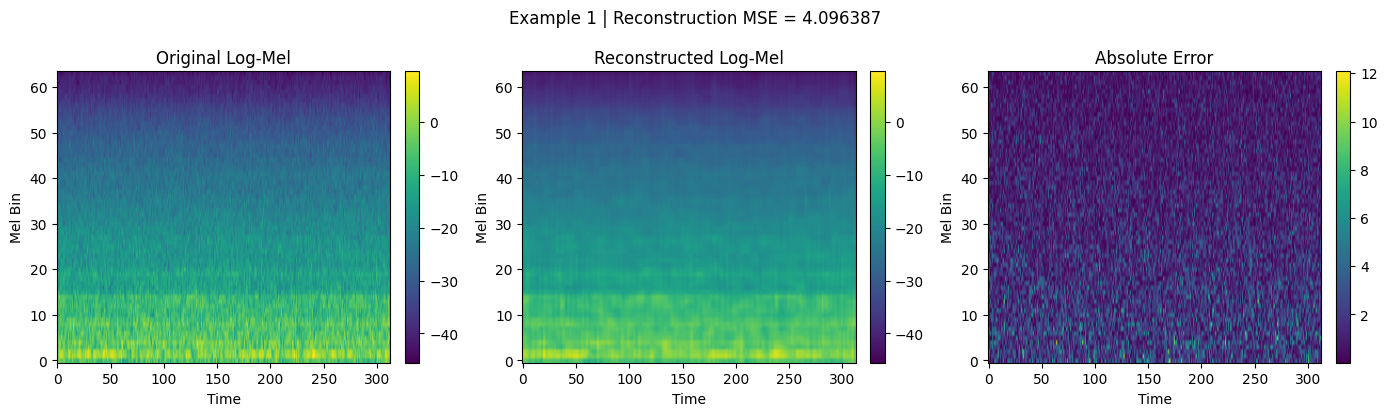

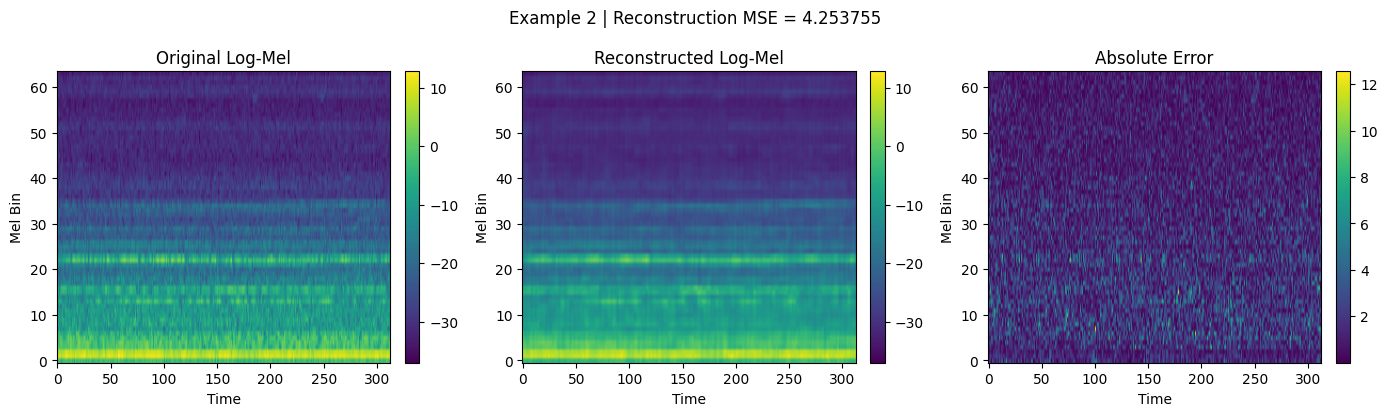

In [25]:
# ==============================================================
# IMPORTANT:
# Replace the right-hand side below with the EXISTING variables
# from your notebook that already hold the FINAL log-mel images
# for the two examples you are currently visualizing.
#
# They should each be one of:
# - [64, 313]
# - [1, 64, 313]
# - [1, 1, 64, 313]
#
# ==============================================================

EXAMPLE_1_LOGMEL = normal_log_mel_spectrogram   
EXAMPLE_2_LOGMEL = abnormal_log_mel_spectrogram   

# Optional titles: update if you already know the labels / filenames
EXAMPLE_1_TITLE = "Example 1"
EXAMPLE_2_TITLE = "Example 2"

# Run reconstruction
result_1 = run_autoencoder_reconstruction(autoencoder_model, EXAMPLE_1_LOGMEL)
result_2 = run_autoencoder_reconstruction(autoencoder_model, EXAMPLE_2_LOGMEL)

# Plot
plot_autoencoder_reconstruction_triplet(result_1, example_title=EXAMPLE_1_TITLE)
plot_autoencoder_reconstruction_triplet(result_2, example_title=EXAMPLE_2_TITLE)

### Interpretation

If both normal and abnormal examples are reconstructed similarly well, the reconstruction error may not separate the classes clearly.

This visual comparison helps explain why the autoencoder approach struggled: abnormal samples can still remain structurally similar enough to normal samples in log-mel space that reconstruction error is not strongly discriminative.